# Підготовка даних

In [1]:
# Завантажуємо усі потрібні нам бібліотеки

import calendar
import duckdb
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
import seaborn as sns


In [2]:
df = pd.read_csv('retail_store_sales.csv')

# Аналіз перед початком роботи

df.shape

(12575, 11)

In [3]:
# Подивимось на данні ближче

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [4]:
# Перевіряємо на наявність дублікатів
df[df.duplicated()]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [5]:
# Огляд набору данних

df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [6]:
# Познайомимося з числовими характеристиками

df.select_dtypes("number").describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


- Мінімальна ціна за одиницю товару (Price Per Unit) становить 5, а максимальна 41. Середнє та медіана близькі за значенням. Маємо нормальний розподіл даних.

- Максимальна кількість (Quantity) 10 , а мінімальна 1 , поглянувши на серенє та медіану також можемо сказати, що розподіл ближче до нормального.

- Загальна сума витрат (Total Spent) має досить широкий діапазон 5 - 410 , з медіанною в 108, можемо сказати що маємо лівосторонній розподіл і велику кількість високих значень.



In [7]:
# Перевіряємо пропущені значення

df.isna().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


In [8]:
# Замінемо пропущені значення

# Товар буде під назвою 'Не визачено'
df['Item'] = df['Item'].fillna('Unknown')

# Замінемо на медіанне значення для кожної з категорій
df['Price Per Unit'] = (
    df.groupby('Category')['Price Per Unit']
    .transform(lambda x: x.fillna(x.median()))
)

# Замінемо медіанною кількістю
df['Quantity'] = df['Quantity'].fillna(
    df['Quantity'].median()
)

# Загaльна сума покупки визначеться шяхом множення ціни за одиницю товару на кількість
df['Total Spent'] = (
    df['Price Per Unit'] * df['Quantity']
)

# Пропущені значення - замінемо на відсутність знижки
df['Discount Applied'] = (
    df['Discount Applied'].fillna('No')
)

In [9]:
# Переведемо до одного формату

df['Discount Applied'] = (
    df['Discount Applied']
    .replace({'No': False})
    .astype('boolean')
)

/tmp/ipykernel_31643/1421192265.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'No': False})


In [10]:
# Перевіремо

df.isna().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [11]:
# Розбиваю нашу колонку Transaction Date на рік/місяць/день/день тижня/квартал для подальшого аналізу

df['Transaction Date'] = pd.to_datetime(
    df['Transaction Date']
)

df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day
df['Weekday'] = df['Transaction Date'].dt.day_name()
df['Quarter'] = df['Transaction Date'].dt.quarter
df['Year_Month'] = (df['Transaction Date'].dt.strftime('%Y-%m'))

In [12]:
# Ковертуємо в інший тип данних

df = df.astype({
    'Year' : 'int64',
    'Month' : 'int64',
    'Day' : 'int64',
    'Quarter' : 'int64'
})

In [13]:
# Перетворемо в datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Робимо індексом для подальших обчислень
df = df.set_index('Transaction Date')

In [14]:
df.to_csv('retail_store_sales2.csv', index=False)

In [15]:
con = duckdb.connect('analytics.duckdb')  # створиться файл analytics.duckdb

# Створюємо таблицю з CSV
con.execute("""
    CREATE OR REPLACE TABLE retail_store AS
    SELECT * FROM 'retail_store_sales2.csv'
""")

# Перевіряємо
print(con.sql('SELECT COUNT(*) AS rows FROM retail_store').df())


    rows
0  12575


**Питанння 1.** Яка кількість унікальних покупців в нашій базі даних?

In [16]:
con.sql("""
    SELECT COUNT(DISTINCT "Customer ID") AS unique_customers
    FROM retail_store
""").df()

,unique_customers
0,25


Наша клієнтська база складається 25 з постіних клієнтів.

**Питання 2.**

- Revenue

- Average Order Value

- Growth Rate

Яка динаміка продажів за роками/місяцями/кварталами, в розрізі рік/місяць? Та яка кількість транзакцій?

In [17]:
# Загальна виручка

con.sql("""
    SELECT ROUND(SUM ("Total Spent"), 2) AS Revenue
    FROM retail_store
""").df()

,Revenue
0,1638628.5


In [18]:
# Поглянемо динаміку в розрізі років

con.sql("""
    SELECT
    "Year",
    ROUND(SUM ("Total Spent"), 2) AS Revenue
    FROM retail_store
    GROUP BY "Year"
""").df()

,Year,Revenue
0,2022,540007.0
1,2023,515909.0
2,2024,555697.0
3,2025,27015.5


In [19]:
# Зміни у % між роками

con.sql("""
    SELECT
        "Year",

        ROUND(SUM("Total Spent"), 2) AS Revenue,

        ROUND(
            (
                SUM("Total Spent")
                - LAG(SUM("Total Spent")) OVER (ORDER BY "Year")
            )
            / LAG(SUM("Total Spent")) OVER (ORDER BY "Year")
            * 100,
            2
        ) AS Growth_Percent

    FROM retail_store
    WHERE "Year" != 2025
    GROUP BY "Year"
    ORDER BY "Year"
""").df()

,Year,Revenue,Growth_Percent
0,2022,540007.0,NaN
1,2023,515909.0,-4.46
2,2024,555697.0,7.71


In [20]:
# Кількість транзакцій за роками

con.sql("""
    SELECT
        "Year",
        COUNT("Transaction ID") AS count_transaction
    FROM retail_store
    GROUP BY "Year"
""").df()

,Year,count_transaction
0,2022,4134
1,2023,3987
2,2024,4241
3,2025,213


In [21]:
# По місяцях

con.sql("""
    SELECT
    "Month",
    ROUND(SUM ("Total Spent"), 2) AS Revenue
    FROM retail_store
    GROUP BY "Month"
""").df()

,Month,Revenue
0,1,183461.5
1,2,127480.5
2,3,130139.5
3,4,132415.0
4,5,131730.0
5,6,136378.5
6,7,139250.5
7,8,129086.5
8,9,134420.0
9,10,125982.0


In [22]:
# Динаміка за кварталами

con.sql("""
    SELECT
    "Quarter",
    ROUND(SUM ("Total Spent"), 2) AS Revenue
    FROM retail_store
    GROUP BY "Quarter"
""").df()

,Quarter,Revenue
0,1,441081.5
1,2,400523.5
2,3,402757.0
3,4,394266.5


In [23]:
# Прибуто за місяць/рік

sales_by_year_month = df.groupby('Year_Month')['Total Spent'].sum()

sales_by_year_month.to_frame().style \
    .background_gradient(cmap='viridis') \
    .format('{:,.0f}')

,Total Spent
Year_Month,
2022-01,"55,985"
2022-02,"45,832"
2022-03,"43,108"
2022-04,"42,581"
2022-05,"42,029"
2022-06,"44,619"
2022-07,"47,598"
2022-08,"43,506"
2022-09,"47,765"


In [24]:
# Середня сума одного замовлення

aov = (
    df['Total Spent'].sum() /
    df['Transaction ID'].nunique()
)

print(aov.round(2))

130.31


In [25]:
# Зміни середнього чеку протягом року

monthly_stats = df['Total Spent'].resample('ME').agg(['mean', 'max', 'min'])

(
    monthly_stats.style
    .format('{:.2f}')
    .background_gradient(cmap='Reds', subset=['min'])
    .background_gradient(cmap='Blues', subset=['mean'])
    .background_gradient(cmap='Greens', subset=['max'])
)

,mean,max,min
Transaction Date,,,
2022-01-31 00:00:00,143.55,410.00,6.50
2022-02-28 00:00:00,138.47,410.00,5.00
2022-03-31 00:00:00,122.12,410.00,5.00
2022-04-30 00:00:00,123.07,380.00,5.00
2022-05-31 00:00:00,127.36,410.00,5.00
2022-06-30 00:00:00,132.01,410.00,5.00
2022-07-31 00:00:00,128.30,410.00,6.50
2022-08-31 00:00:00,125.38,410.00,8.00
2022-09-30 00:00:00,137.26,410.00,9.50


In [26]:
years = df.index.year.unique()

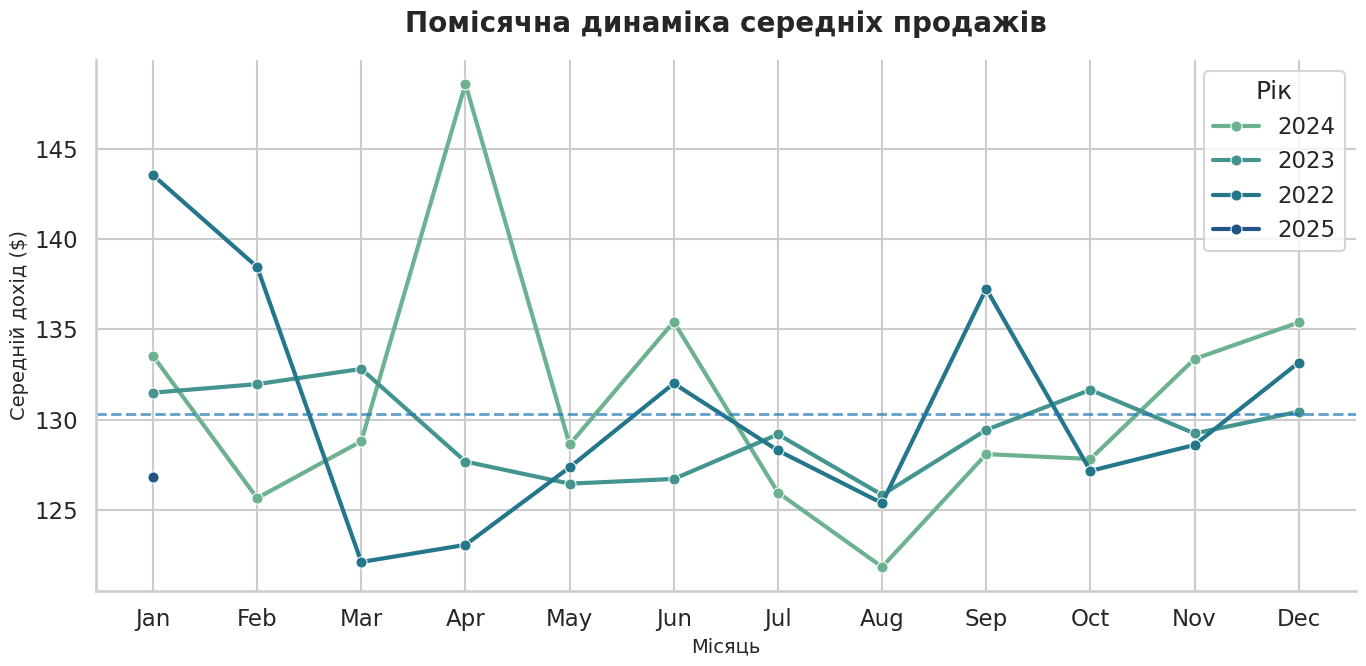

In [27]:
sns.set_style("whitegrid")
sns.set_context("talk")


colors = sns.color_palette("crest", n_colors=len(years))

fig, ax = plt.subplots(figsize=(14, 7))


for color, y in zip(colors, years):

    yearly_data = df[df.index.year == y]

    monthly_avg = (
        yearly_data['Total Spent']
        .resample('ME')
        .mean()
    )

    sns.lineplot(
        x=monthly_avg.index.month,
        y=monthly_avg.values,
        marker='o',
        linewidth=3,
        markersize=8,
        label=str(y),
        color=color,
        ax=ax
    )


ax.set_title(
    'Помісячна динаміка середніх продажів',
    fontsize=20,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Місяць', fontsize=14)
ax.set_ylabel('Середній дохід ($)', fontsize=14)

months = range(1, 13)

ax.set_xticks(months)
ax.set_xticklabels(
    [calendar.month_abbr[m] for m in months]
)


ax.legend(
    title='Рік',
    frameon=True,
    fancybox=True
)


sns.despine()
overall_avg = df['Total Spent'].mean()

ax.axhline(
    overall_avg,
    linestyle='--',
    linewidth=2,
    alpha=0.7,
    label='Overall Average'
)

plt.tight_layout()
plt.show()

In [28]:
sales_by_year = df.groupby('Year')['Total Spent'].sum()


sales_by_month = df.groupby('Month')['Total Spent'].sum()


sales_by_quarter = df.groupby('Quarter')['Total Spent'].sum()

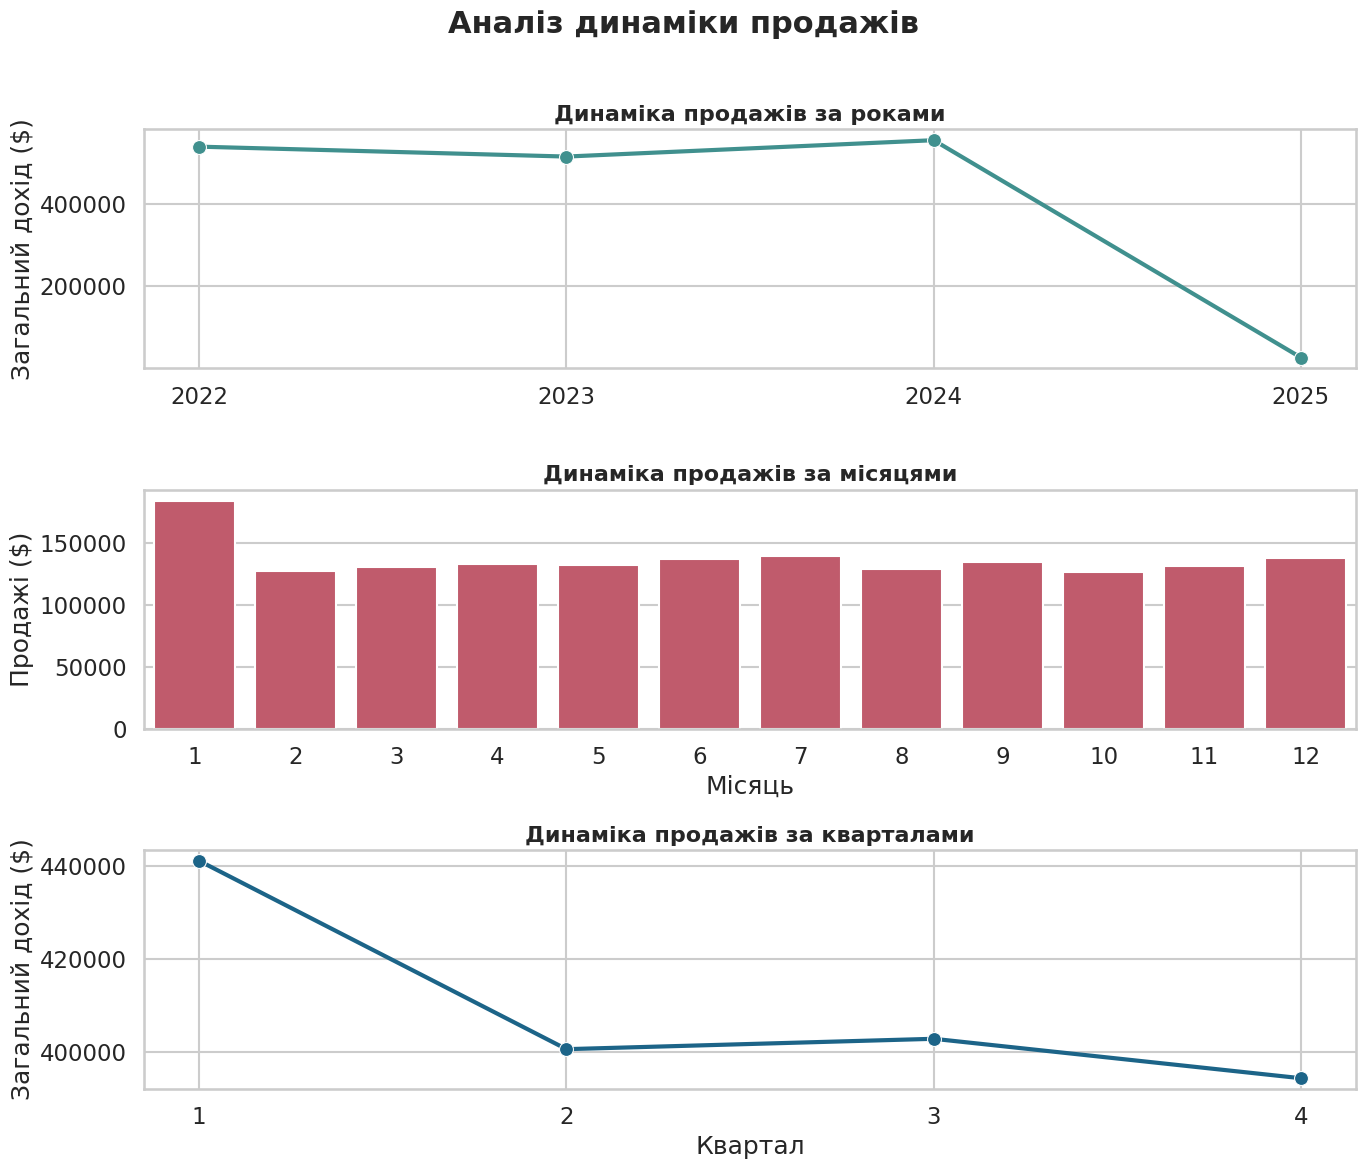

In [29]:
sns.set_style("whitegrid")
sns.set_context("talk")

palette = sns.color_palette("crest")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))


sns.lineplot(
    x=sales_by_year.index,
    y=sales_by_year.values,
    marker='o',
    linewidth=3,
    markersize=10,
    color=palette[2],
    ax=axes[0]
)

axes[0].set_title(
    'Динаміка продажів за роками',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Загальний дохід ($)')
axes[0].set_xlabel('')

axes[0].set_xticks([2022, 2023, 2024, 2025])


sns.barplot(
    x=sales_by_month.index,
    y=sales_by_month.values,
    color=sns.color_palette("flare")[2],
    ax=axes[1]
)

axes[1].set_title(
    'Динаміка продажів за місяцями',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xlabel('Місяць')
axes[1].set_ylabel('Продажі ($)')

sns.lineplot(
    x=sales_by_quarter.index,
    y=sales_by_quarter.values,
    marker='o',
    linewidth=3,
    markersize=10,
    color=palette[4],
    ax=axes[2]
)

axes[2].set_title(
    'Динаміка продажів за кварталами',
    fontsize=16,
    fontweight='bold'
)

axes[2].set_xlabel('Квартал')
axes[2].set_ylabel('Загальний дохід ($)')

axes[2].set_xticks([1, 2, 3, 4])


fig.suptitle(
    'Аналіз динаміки продажів',
    fontsize=22,
    fontweight='bold'
)


plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

Перевіремо , за допомогою Analysis of Variance чи дійсно є статистично значуща різниця в середньомісячному доході між роками.

H₀:

Середній місячний дохід однаковий між роками однаковий.

H₁:

Хоча б один рік має інший середній місячний дохід.

In [30]:
# Підготуємо данні

monthly_revenue = (
    df.groupby(['Year', 'Month'])['Total Spent']
    .sum()
    .reset_index()
)

In [31]:
# ANOVA тест

groups = [
    group['Total Spent'].values
    for _, group in monthly_revenue.groupby('Year')
]

f_stat, p_value = f_oneway(*groups)

print('F-statistic:', f_stat)
print('p-value:', p_value)

F-statistic: 9.801607232882606
p-value: 9.01948867371071e-05


Результати тесту показали  , що p_value >= 0.05, це означає , що середній місячний дохід за роками не має статистично значущої різниці. Це підтверджує нашу H₀.

Це означає, що дохід стабільний та суттєвих змін не було,поведінка нашого покупця не змінилася.

- Загальний дохід - 1,638,628.5 $ (враховуючи початок 2025)

- Маємо спад по продажам у 2023 році - 4.46 % , після зростання у 2024 - 7.71 %.

- 2025 - не доречно брати до уваги, адже маємо данні лише за перший місяць.

- Найбільше продажів за роками в 1 кварталі року.

- Найприбутковіший місяць за роками - січень.

- Найвищий середні чек зафіксовано в квітні 2024 року, а найнижчий березень 2022 та серпень 2024.

- Найвищі продажі в розрізі місяць/рік спостерігаємо в січні 2022, січень 2023, грудень 2024, січень 2024, що підтверджує спостереження про найвищі продажі в 1 кварталі року.

- Середня сума одного замовлення становить - 130.3 $.

**Питання 3.**

- Basket Size

Які товари купують найчастіше? Яка середня кількість товарів в чеку та які 20% товарів дають 80% виручки?

In [32]:
# Середня кількість товарів в кошику

basket_size = (
    df['Quantity'].sum() /
    df['Transaction ID'].nunique()
)

print(basket_size.round(2))

5.56


In [33]:
# Товари, що продаються найчастіше

top_quantity = (
    df.groupby('Item')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

In [34]:
# Дли чистоти аналізу приберемо категорію Не визначено

top_quantity = top_quantity[
    top_quantity.index != 'Unknown'
]

print(top_quantity.head(10))

Item
Item_2_BEV      676.0
Item_16_MILK    627.0
Item_25_FUR     616.0
Item_19_MILK    589.0
Item_13_FOOD    581.0
Item_5_FUR      581.0
Item_1_MILK     578.0
Item_11_MILK    574.0
Item_11_FUR     573.0
Item_14_FOOD    566.0
Name: Quantity, dtype: float64


In [35]:
# Товари , що приносять найбільший прибуток

top_revenue = (
    df.groupby('Item')['Total Spent']
    .sum()
    .sort_values(ascending=False)
)

top_revenue = top_revenue[
    top_revenue.index != 'Unknown'
]

print(top_revenue.head(10))

Item
Item_25_FUR     25256.0
Item_25_EHE     23083.0
Item_25_BUT     21894.0
Item_24_FUR     21172.0
Item_25_FOOD    20541.0
Item_22_BUT     19710.0
Item_23_BUT     19114.0
Item_20_BUT     18860.5
Item_19_MILK    18848.0
Item_23_EHE     18468.0
Name: Total Spent, dtype: float64


In [36]:
# Розділимо на класи

abc = (
    df.groupby('Item')['Total Spent']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

abc['Revenue Share'] = (
    abc['Total Spent'] /
    abc['Total Spent'].sum()
)

abc['Cumulative Share'] = (
    abc['Revenue Share'].cumsum()
)

abc['Class'] = 'C'

abc.loc[
    abc['Cumulative Share'] <= 0.80,
    'Class'
] = 'A'

abc.loc[
    (abc['Cumulative Share'] > 0.80) &
    (abc['Cumulative Share'] <= 0.95),
    'Class'
] = 'B'

abc.head(10)

,Item,Total Spent,Revenue Share,Cumulative Share,Class
0,Unknown,165630.0,0.101078,0.101078,A
1,Item_25_FUR,25256.0,0.015413,0.116491,A
2,Item_25_EHE,23083.0,0.014087,0.130578,A
3,Item_25_BUT,21894.0,0.013361,0.143939,A
4,Item_24_FUR,21172.0,0.012921,0.156860,A
5,Item_25_FOOD,20541.0,0.012535,0.169395,A
6,Item_22_BUT,19710.0,0.012028,0.181424,A
7,Item_23_BUT,19114.0,0.011665,0.193088,A
8,Item_20_BUT,18860.5,0.011510,0.204598,A
9,Item_19_MILK,18848.0,0.011502,0.216101,A


In [37]:
# Приберемо за аналізу Unknown, не доречно його враховувати в аналізі, адже це відсутні значення

abc = abc[abc['Item'] != 'Unknown']

abc.head(10)

,Item,Total Spent,Revenue Share,Cumulative Share,Class
1,Item_25_FUR,25256.0,0.015413,0.116491,A
2,Item_25_EHE,23083.0,0.014087,0.130578,A
3,Item_25_BUT,21894.0,0.013361,0.143939,A
4,Item_24_FUR,21172.0,0.012921,0.156860,A
5,Item_25_FOOD,20541.0,0.012535,0.169395,A
6,Item_22_BUT,19710.0,0.012028,0.181424,A
7,Item_23_BUT,19114.0,0.011665,0.193088,A
8,Item_20_BUT,18860.5,0.011510,0.204598,A
9,Item_19_MILK,18848.0,0.011502,0.216101,A
10,Item_23_EHE,18468.0,0.011270,0.227371,A


In [38]:
# Розподіленя за класами по загальному прибутку

abc.groupby('Class')['Total Spent'].sum()

,Total Spent
Class,
A,1138761.5
B,252068.0
C,82169.0


In [39]:
# Розподілення за кількість

abc["Class"].value_counts()

,count
Class,
A,93
B,54
C,53


- Середня кількість товарі в кошику 5.5.

- Товар Unknown дає більше 10% виручки, при цьому спотворюючи наш аналіз , адже Unknown - це наші пропущені значення. Щоб аналіз був реалістичним , явиключу цю категорію з аналізу.

- Проаналізувавши наші дані : 93 (20%) товари дають 80 % доходу - 1138761.5 $. Рекомендую слідкувати за наявістю товарів з групи А, контролювати запаси та спрямувати маркетингову кампанію.

**Питання 3.** Скільки клієнт приносить нам грошей?
Вище ми визначили , що маємо 25 постійних клієнтів.
Який середній чек наших клієнтів? Та чи впливає спосіб оплати на середній чек?

In [40]:
# Запит на топ - 5 клієнтів

con.sql("""
    SELECT
        "Customer ID",
        SUM("Total Spent") AS LTV
    FROM retail_store
    GROUP BY "Customer ID"
    ORDER BY LTV DESC
    LIMIT 5
""").df()

,Customer ID,LTV
0,CUST_24,71561.5
1,CUST_08,70477.5
2,CUST_05,70274.5
3,CUST_13,69247.5
4,CUST_23,68137.0


In [41]:
# Середній чек за клієнтами та типом оплати

con.sql("""
    SELECT
        "Customer ID",
        "Payment Method",
        ROUND(AVG("Total Spent"), 2) AS AVG_bill
    FROM retail_store
    GROUP BY "Payment Method", "Customer ID"
    ORDER BY AVG_bill DESC
    LIMIT 5
""").df()


,Customer ID,Payment Method,AVG_bill
0,CUST_03,Cash,148.63
1,CUST_21,Credit Card,144.17
2,CUST_25,Cash,143.10
3,CUST_19,Cash,142.11
4,CUST_17,Digital Wallet,141.83


- Визначили топ - 5 клієнтів за покупками та топ - 5 клієнтів з найвищим середнім чеком і це різні клієнти. Це означає, ще перші роблять у нас часті покупки та регулярно повертуються, а друга група  - купує рідше, але на великі суми.

- Вищий середній чек переважно у клієнтів платять готівкою та кредитною карткою.

- Найвищий середній чек за клієнтами знаходиться в межах 141 - 148 $.

**Питання 4.** Який тип оплати замовлень переважає ?
Який метод оплати використовують для великих покупок?

In [42]:
# Розподіл за типом оплати

method_type = df.groupby('Payment Method')['Payment Method'].count()
method_type

,Payment Method
Payment Method,
Cash,4310
Credit Card,4121
Digital Wallet,4144


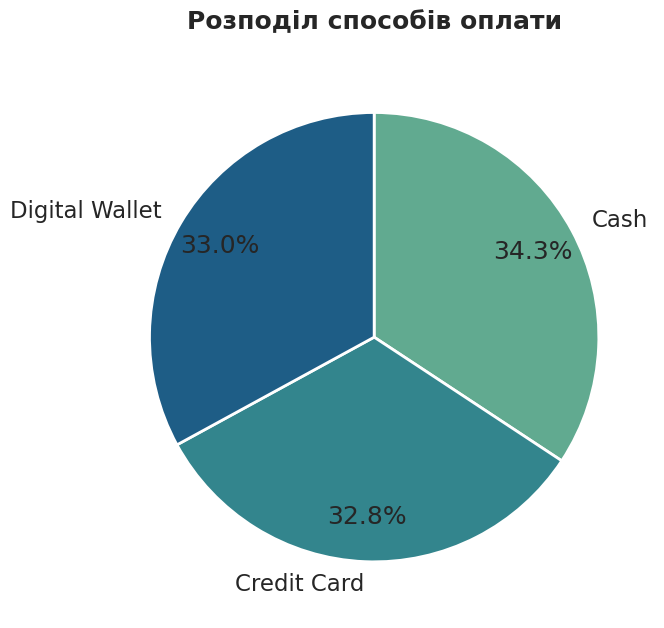

In [43]:
sns.set_style('white')

fig, ax = plt.subplots(figsize=(7, 7))


method_type.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.8,
    colors=sns.color_palette('crest', len(method_type)),
    ax=ax
)


ax.set_title(
    'Розподіл способів оплати',
    fontsize=18,
    fontweight='bold',
    pad=20
)


ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [44]:
# 1. Визначаємо поріг великої покупки
threshold = df['Total Spent'].quantile(0.75)  # верхні 25%

# 2. Фільтруємо великі покупки
large_purchases = df[df['Total Spent'] >= threshold]

# 3. Дивимось популярність методів оплати
payment_stats = (
    large_purchases['Payment Method']
    .value_counts()
)

print(payment_stats)

Payment Method
Cash              1122
Digital Wallet    1044
Credit Card       1037
Name: count, dtype: int64


In [45]:
#Поглянемо у відстоках

payment_percent = (
    large_purchases['Payment Method']
    .value_counts(normalize=True) * 100
).round(2)

print(payment_percent)

Payment Method
Cash              35.03
Digital Wallet    32.59
Credit Card       32.38
Name: proportion, dtype: float64


**Статистичний тест**


- H₀ (нульова гіпотеза)

Тип оплати не пов’язаний із розміром покупки.

- H₁ (альтернативна)

Тип оплати пов’язаний із розміром покупки.

Та давайте пересвідчимося за допомогою статистичного тестування, чи дійсно є статистично значуща різниця між типом оплати та великими покупками. Використаємо χ² (хи-квадрат) тест незалежності.

In [46]:
#Створимо категорію покупок

threshold = df['Total Spent'].median()

df['Purchase Type'] = np.where(
    df['Total Spent'] >= threshold,
    'Large',
    'Small'
)

In [47]:
#Збудуємо таблицю частот

contingency_table = pd.crosstab(
    df['Payment Method'],
    df['Purchase Type']
)

print(contingency_table)

Purchase Type   Large  Small
Payment Method              
Cash             2205   2105
Credit Card      2072   2049
Digital Wallet   2092   2052


In [48]:
#Виконуємо χ² тест

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f'Chi2: {chi2:.2f}')
print(f'p-value: {p:.4f}')

Chi2: 0.72
p-value: 0.6970


За допомогою χ²-тесту незалежності було перевірено, чи пов’язаний метод оплати з розміром покупки. Результати показали, що p-value = 0.6970. Це свідчить, що між типом оплати та величиною чека немає статистично значущого зв’язку.

**Питання 5.** Яка локація користується попитом серед наших клієнтів?

In [49]:
# Розподіл за місцем оплати

transaction_location = (
    df.groupby('Location')['Location']
    .count()
)

transaction_percent = (
    transaction_location / transaction_location.sum()
) * 100

print((transaction_percent).round(2))


Location
In-store    49.47
Online      50.53
Name: Location, dtype: float64


- Розподіл за місцем оплатити рівномірний , не має значної переваги.

**Питання 6.** Яка група товарів приносить нам більшу виручку за роками ?

In [50]:
# Розподіл загального доходу за категоріями та роками

spent_by_year = df.pivot_table(
    index = 'Year',
    columns = 'Category',
    values = 'Total Spent',
    aggfunc = 'sum'
)

spent_by_year

Category,Beverages,Butchers,Computers and electric accessories,Electric household essentials,Food,Furniture,Milk Products,Patisserie
Year,,,,,,,,
2022,66748.5,82334.0,61673.5,74369.5,61701.5,64880.5,61194.5,67105.0
2023,57832.5,62936.5,65818.5,67915.0,70119.5,65279.0,65714.5,60293.5
2024,78863.0,69573.0,70271.0,69368.5,69390.0,71985.0,60885.0,65361.5
2025,3749.5,3849.5,4590.5,2984.5,4473.0,3179.5,2408.5,1780.5


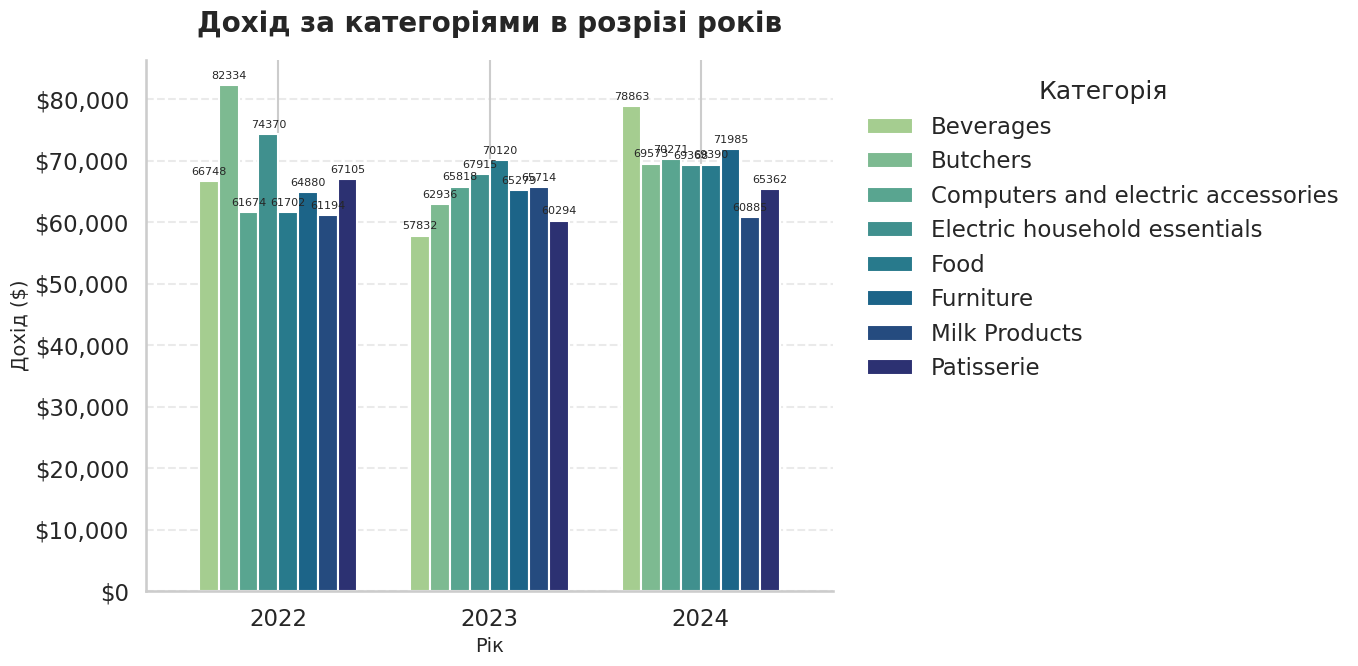

In [51]:
sns.set_style("whitegrid")
sns.set_context("talk")

filtered_data = spent_by_year.drop(index=2025)


ax = filtered_data.plot(
    kind='bar',
    figsize=(14, 7),
    colormap='crest',
    width=0.75
)


ax.set_title(
    'Дохід за категоріями в розрізі років',
    fontsize=20,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Рік', fontsize=14)
ax.set_ylabel('Дохід ($)', fontsize=14)

ax.tick_params(axis='x', rotation=0)


ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)


ax.legend(
    title='Категорія',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3,
        fontsize=8
    )

sns.despine()

plt.tight_layout()
plt.show()

Ці категорії є основним джерелом доходу

- Butchers
- Electric household essentials
- Beverages

Порінявши 2022 та 2023 роки помічаємо яскраву тенденцію спаду абсолютно за всіма категоріями, можливо події у світі, криза вплинули на нашу дохідність.

До 2024 наші показники виросли, окрім категорії Молочні продукти , що може свідчити про високий рівень конкуренції, зниження попиту.

**Питання 7.**

- Product Analysis

Які категорії є найприбутковішими? Який середній чек за категоріями товарів?

In [52]:
# Топ - 5 категорій товарів

con.sql("""
    SELECT
        "Category",
        SUM("Total Spent") AS Revenue
    FROM retail_store
    GROUP BY "Category"
    ORDER BY revenue DESC
    LIMIT 5
""").df()

,Category,Revenue
0,Butchers,218693.0
1,Electric household essentials,214637.5
2,Beverages,207193.5
3,Food,205684.0
4,Furniture,205324.0


In [53]:
# Середній чек за категоріями

avg_bill_by_category = df.pivot_table(
    values = "Total Spent",
    index = "Category",
    aggfunc = "mean"
)

avg_bill_by_category.sort_values(
    by = "Total Spent",
    ascending = False
).round(2)

,Total Spent
Category,
Butchers,139.47
Electric household essentials,134.91
Beverages,132.22
Computers and electric accessories,129.88
Food,129.52
Furniture,129.05
Patisserie,127.32
Milk Products,120.08


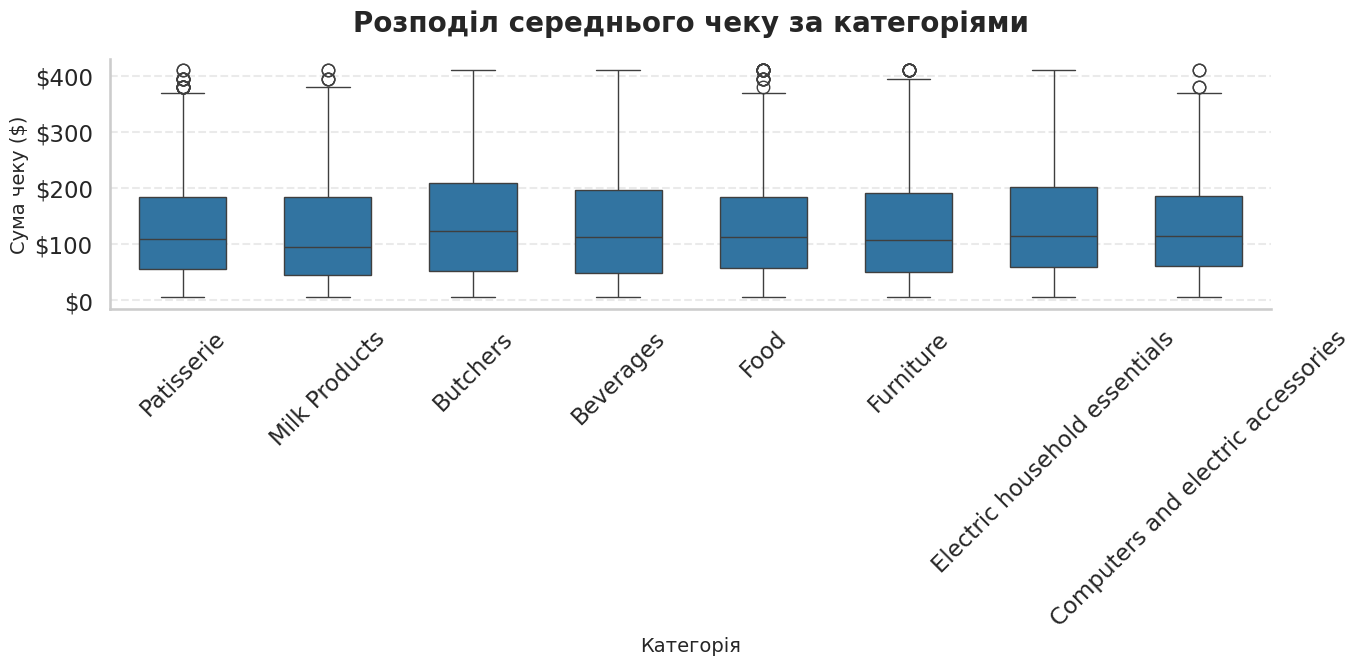

In [54]:
sns.set_style("whitegrid")
sns.set_context("talk")


fig, ax = plt.subplots(figsize=(14, 7))


sns.boxplot(
    data=df,
    x='Category',
    y='Total Spent',
    width=0.6,
    ax=ax
)

ax.set_title(
    'Розподіл середнього чеку за категоріями',
    fontsize=20,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Категорія', fontsize=14)
ax.set_ylabel('Сума чеку ($)', fontsize=14)


ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)


ax.tick_params(axis='x', rotation=45)


ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)


sns.despine()

plt.tight_layout()
plt.show()

- Переважно всі коробки мають правосторонній розподіл - медіана знаходиться лівіше, це означає , що в нас більше великих значень, за винятком Butchers, я б сказала, що розподіл рівномірний, або наближений.

- Коробки приблизно однакового розміру, що означає маємо подібний розкид данних.

- Маємо аутлаєрів - це наші великі чеки, нетипові покупки, аномальні значення  - Patisserie, Milk Products, Food, Furniture, Computers and electric accessories.

- 'Вуса' у всіх категоріях досить довгі - маємо широкий розкид значень, що свідчить про нестабільну поведінку.


Найвищий середній чек та дохідність в категоріях:

- М'ясні продукти
- Електропобутові речі першої необхідності
- Напої


Це найцініші категорії для нашого бізнесу, адже покупці витрачають великі суми грошей за одну покупку і в категорії великий сумарний обсяг продажів.
Це свідчить про те що, на категорії високий попит та ціна, клієнти готові платити.


**Питання 8.** Яка динаміка продажів категорій товарів за місяцями? Чи прослідковується певна сезонність?


In [55]:
# Помісячний прибуток за категоріями

category_total_spent_by_month = df.pivot_table(
    values = 'Total Spent',
    columns = 'Category',
    index = 'Month',
    aggfunc = 'sum'
)

category_total_spent_by_month.round(2)

Category,Beverages,Butchers,Computers and electric accessories,Electric household essentials,Food,Furniture,Milk Products,Patisserie
Month,,,,,,,,
1,23572.5,25244.0,26303.0,22231.5,23836.0,22693.5,20074.0,19507.0
2,17840.0,18638.0,13972.5,17870.5,14547.5,16288.5,13283.5,15040.0
3,15665.5,14203.0,15167.0,16729.5,16480.0,17148.0,17293.5,17453.0
4,14323.5,17122.0,18722.0,18150.0,13149.0,20997.0,13571.0,16380.5
5,18016.5,16858.5,13133.0,18618.5,17265.0,16158.0,15107.5,16573.0
6,16859.5,19642.5,19592.5,19209.5,14252.5,16380.0,12867.0,17575.0
7,19073.5,18943.0,16338.5,18543.5,20110.0,15949.0,16611.5,13681.5
8,16334.0,17410.0,14664.0,16714.0,15366.5,18489.5,14316.5,15792.0
9,17411.5,17663.5,16419.0,18104.5,17191.5,14786.0,17952.0,14892.0


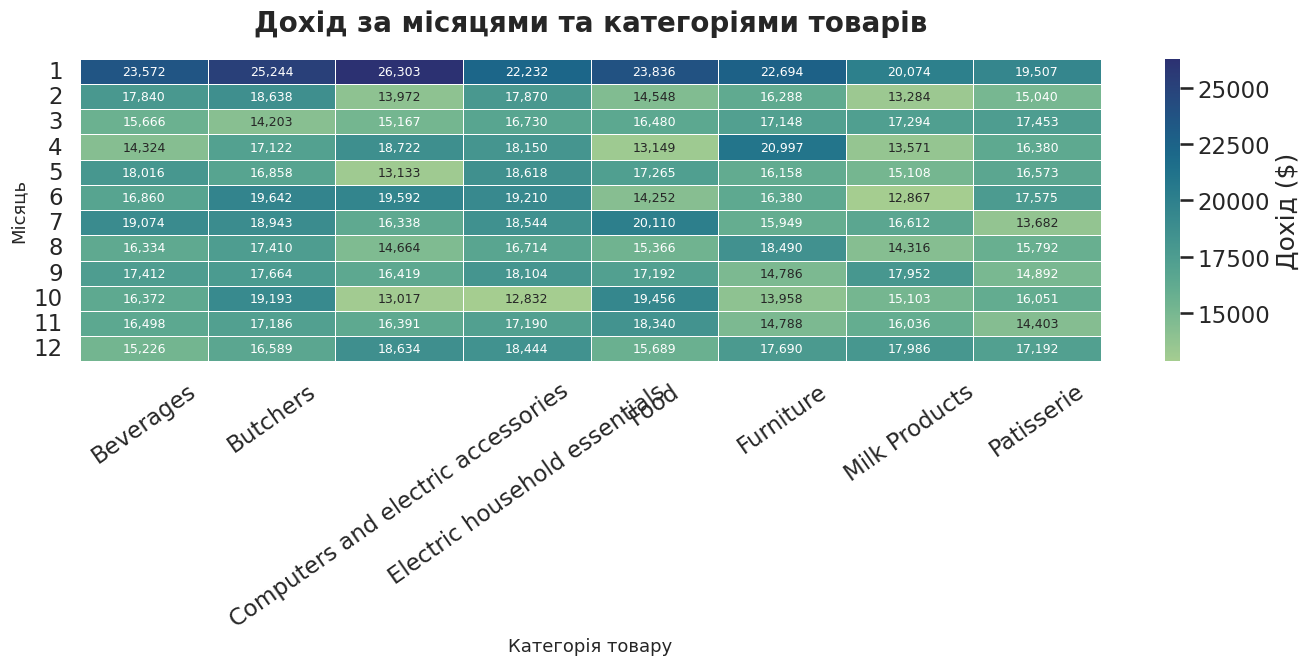

In [56]:
sns.set_style("white")
sns.set_context("talk")


fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    category_total_spent_by_month,
    annot=True,
    fmt=',.0f',
    cmap='crest',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Дохід ($)'},
    annot_kws={'size': 9},
    ax=ax
)


ax.set_title(
    'Дохід за місяцями та категоріями товарів',
    fontsize=20,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Категорія товару', fontsize=13)
ax.set_ylabel('Місяць', fontsize=13)


ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

Аналіз помісячного доходу показав наявність сезонності в окремих категоріях товарів. Найвищі продажі для більшості категорій спостерігаються у січні, що може бути пов’язано зі святковим періодом та сезонними акціями. Після цього у лютому–березні спостерігається спад продажів.

Категорія Computers and electric accessories характеризується найбільшою варіативністю та вираженими піками попиту, тоді як Food і Beverages демонструють більш стабільний попит протягом року. Це свідчить про різний рівень сезонної залежності між категоріями товарів.


**Питання 9.** Чи є певна закономірність між типом оплати, місцем та категорією?

In [57]:
# Закономірність між типом оплати, локаціє та категоріями

location_transaction = df.pivot_table(
    index = 'Category',
    columns = ['Payment Method', 'Location'],
    values = 'Total Spent',
    aggfunc = 'sum'
)

location_transaction.style.background_gradient(cmap='crest')

- Electric household essentials - оплата переважає онлайн гаманцем , а покупка в онлайн магазині. Наш клієнт обирає безготівкові оплати для більш дорогих товарів.
- Категорія Food користується в рівній популяронсті, як онлайн так і у фізичних магазинах.
- Computers and electric accessories обирають онлайн, що є зручно для більш габаритних замовлень.

**Питання 10.**

RFM Analysis

Repeat Purchase Rate

Яка поведінка наших клієнтів? Як часто купують? ЯК давно бути востаннє?


In [58]:
# Створюємо RFM таблицю

snapshot_date = df.index.max()

rfm = df.groupby('Customer ID').agg(
    Frequency=('Transaction ID', 'count'),
    Monetary=('Total Spent', 'sum'),
    LastPurchase=('Transaction ID', lambda x: x.index.max())
)

rfm['Recency'] = (snapshot_date - rfm['LastPurchase']).dt.days
rfm = rfm.drop(columns='LastPurchase')

In [59]:
# Перейменовуємо колонки
# Recency - на скільки активний, Frequency - лояльність  , Monetary' - цінність клієнта.

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [60]:
# Перевіримо наші данні

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST_01,507,62507.0,0
CUST_02,488,65427.5,2
CUST_03,465,63545.5,2
CUST_04,474,64479.5,0
CUST_05,544,70274.5,4


In [61]:
# Сегментуємо наших клієнтів

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=4,
    labels=[4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=4,
    labels=False
) + 1

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=4,
    labels=False
) + 1

In [62]:
# Загальний RFM

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [63]:
# Ділимо на сегменти

rfm['Segment'] = 'Regular'

rfm.loc[
    rfm['RFM_Score'] == '444',
    'Segment'
] = 'VIP'

rfm.loc[
    (rfm['F_Score'].astype(int) >= 3) &
    (rfm['R_Score'].astype(int) >= 3),
    'Segment'
] = 'Loyal'

rfm.loc[
    (rfm['M_Score'].astype(int) == 4) &
    (rfm['Segment'] == 'Regular'),
    'Segment'
] = 'Big Spenders'

rfm.loc[
    rfm['R_Score'].astype(int) == 1,
    'Segment'
] = 'At Risk'

rfm.loc[
    rfm['RFM_Score'] == '444',
    'Segment'
] = 'VIP'

**Як розуміти?**

Recency = 5

- клієнт купував 5 днів тому

Frequency = 12

-  12 покупок

Monetary = 2400

- витратив 2400

In [64]:
rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
CUST_01,507,62507.0,0,2,1,1,211,Regular
CUST_02,488,65427.5,2,3,3,3,333,Loyal
CUST_03,465,63545.5,2,4,1,3,413,Regular
CUST_04,474,64479.5,0,4,2,1,421,Regular
CUST_05,544,70274.5,4,1,4,4,144,At Risk
CUST_06,481,61433.0,2,4,1,3,413,Regular
CUST_07,491,65182.5,0,3,3,1,331,Loyal
CUST_08,533,70477.5,1,1,4,2,142,At Risk
CUST_09,519,64687.5,1,1,2,2,122,At Risk


In [65]:
rfm["Segment"].value_counts()

,count
Segment,
Regular,11
At Risk,6
Loyal,5
Big Spenders,3


In [66]:
rfm.groupby("Segment")["Monetary"].sum()

,Monetary
Segment,
At Risk,7
Big Spenders,11
Loyal,8
Regular,9


- Розділивши наших клієнтів на групи ми побачили такий розподіл

**VIP**

CUST_13

**Loyal**

CUST_01

CUST_08

CUST_09

CUST_11

CUST_15

CUST_24

**Big Spenders**

CUST_16

**At Risk**

CUST_05

CUST_17

CUST_20

CUST_21

CUST_22

CUST_23

- VIP клієнти - це найцінніші клієнти, вони часто купують, багато витрачають , активні.

- Loyal - наші постійні, стабільні клієнти.

- Big Spenders - витрачають багато, але не часто повертаються.

- At Risk - давно не купували , потрібно спрямувати маркетингові дії, щоб клієнт до нас повернувся.

**Питання 11.**

Discount Impact Analysis

Як часто наш клієнт користується знижками та чи це збільшує наші продажі?

In [67]:
# Перевіримо скільки покупок було зі знижкою

(
    df['Discount Applied']
    .value_counts(normalize=True) * 100
).round(2)

,proportion
Discount Applied,
False,66.45
True,33.55


In [68]:
pd.crosstab(
    df['Category'],
    df['Discount Applied'],
    normalize='index'
) * 100

Discount Applied,False,True
Category,,
Beverages,66.751755,33.248245
Butchers,65.369898,34.630102
Computers and electric accessories,65.661104,34.338896
Electric household essentials,67.190446,32.809554
Food,68.010076,31.989924
Furniture,66.373350,33.626650
Milk Products,65.909091,34.090909
Patisserie,66.295812,33.704188


In [69]:
# Середній чек, загальний дохід та кількість транзакцій

discount_stats = (
    df.groupby('Discount Applied')
    .agg({
        'Total Spent': ['mean', 'sum'],
        'Transaction ID': 'count'
    })
)

print((discount_stats).round(2))

                 Total Spent            Transaction ID
                        mean        sum          count
Discount Applied                                      
False                 129.77  1084378.5           8356
True                  131.37   554250.0           4219


In [70]:
# Середній чек за категоріями та використанням знижки

pd.pivot_table(
    df,
    values ='Total Spent',
    index = 'Category',
    columns = 'Discount Applied',
    aggfunc = 'mean'
).style.highlight_max(color = 'lightgreen')

Discount Applied,False,True
Category,,
Beverages,129.145315,138.402111
Butchers,139.167317,140.048803
Computers and electric accessories,132.425220,125.014019
Electric household essentials,133.990178,136.785441
Food,129.581481,129.401575
Furniture,130.457386,126.282243
Milk Products,120.479406,119.300000
Patisserie,122.850938,136.101942


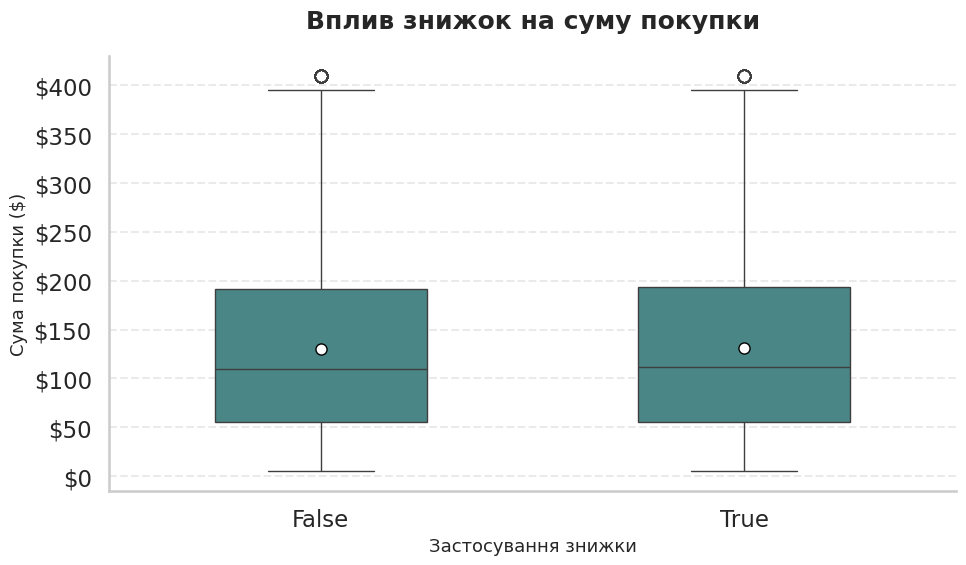

In [71]:
sns.set_style("whitegrid")
sns.set_context("talk")


fig, ax = plt.subplots(figsize=(10, 6))


sns.boxplot(
    data=df,
    x='Discount Applied',
    y='Total Spent',
    color=sns.color_palette("crest")[2],
    width=0.5,
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': 8
    },
    ax=ax
)


ax.set_title(
    'Вплив знижок на суму покупки',
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Застосування знижки', fontsize=13)
ax.set_ylabel('Сума покупки ($)', fontsize=13)


ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)


ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

sns.despine()

plt.tight_layout()
plt.show()

На етапі візуалізації ми вже можемо зробити висновки, що не має статистичної різниці з використанням знижки або без неї.
Бачимо однакової ширини та висоти коробки ,що свідчить про однаковий розкид даних, є точки згори - це наші великі чеки. Медіана на одному рівні, дані розподілені норимально.


- Провівши аналіз можемо зробити висновок, що знижки суттєво не впливають на кількість товарів в чеку, середню ціну та загальну суму покупки.

- Кількість транзакцій зі знижкою - 4219, без знижки - 8356. Це суттєва різниця майже в двічі більше транзакцій проходить без застосування знижки.

- Можливо знижки використовуються для підтримки продажів, а не для збільшення обсягів покупки.

- Середній чек зі знижкою вищий та чи це дійсно статистично значуще? Перевіремо.
Для цього можна використати t-test




In [72]:
discount = (
    df[df['Discount Applied'] == True]['Total Spent']
    .dropna()
)

no_discount = (
    df[df['Discount Applied'] == False]['Total Spent']
    .dropna()
)

print(len(discount), len(no_discount))

t_stat, p_value = ttest_ind(
    discount,
    no_discount,
    equal_var=False
)

print('t-stat:', t_stat)
print('p-value:', p_value)

4219 8356
t-stat: 0.9115862622345751
p-value: 0.3620127989103826


За результатами t-тесту не було виявлено статистично значущої різниці між середнім чеком покупок зі знижкою та без знижки p-value = 0.362. Це свідчить про те, що використання знижки не має суттєвого впливу на суму покупки.

- Клієнти витрачають приблизно однаково незалежно від знижки.
- Акції не збільшують середній чек.
- Знижки лише стимулюють факт покупки, а не її розмір.